[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/brilliantbeaver/alexpose/blob/main/experiments/sjepa/gavd6-pm/03_neurologic_keypoint_masking.ipynb)

# 03. Neurologic keypoint masking

**The question this notebook answers.** Which tokens is S-JEPA allowed to hide and predict, how many of them does it hide, and how do we know the rule was obeyed? Notebook 00 stated the rule in one sentence. This notebook is where it is defined precisely, implemented, and attacked with adversarial tests.

**What it assumes you already have.** From notebook 00: token, joint-time patch, target mask, view encoder, target encoder. From notebook 02: the validity mask and the fact that a badly tracked landmark stays in the tensor rather than disappearing from it.

**What it produces.** No files. It produces the two functions notebook 04 imports without modification, `uniform_neurologic_mask` and `mask_audit`, plus the evidence that they behave as specified.

**What comes next.** Notebook 04 runs the five-stage curriculum, calling `uniform_neurologic_mask` once per training batch.

**Research use only.** This tutorial does not diagnose a person or validate a clinical device.

**Run it:** locally, use `uv sync` then `uv run jupyter lab` from this folder. In Colab, use the badge and run the setup cell. Restart the kernel after changing `experiments/sjepa/gavd6-pm/.env`.

## The two ideas to take away

**Twelve landmark identities are eligible, and only as targets.** The restriction says which tokens may be *hidden and predicted*. It does not restrict what either encoder may *see*. Step 2 makes that distinction exact, and it is the single most common misreading of this design.

**The 0.60 masking fraction is not 60 percent per sample.** It is applied to the **smallest** eligible-token count in the batch, and the resulting count is then used for every sample in that batch. Samples with more eligible tokens are therefore masked at less than 0.60. Step 4 works through why the rule has to be written this way and what the realized fractions turned out to be during real training.

## The seven steps

1. The eligible landmark list, and where it comes from.
2. The restriction is about targets, not context.
3. Create one mask and audit it.
4. Why the realized fraction is not 0.60 per sample.
5. Attack the sampler with adversarial invariants.
6. The policies that are explicitly absent.
7. Why targets are stochastic rather than permanently hidden.

### The three cells before step 1

The first cell is the shared setup cell. The second draws `03_neurologic_mask.svg`. The third is the contract: it restates `BLAZEPOSE_33` and the 12 `MASK_KEYPOINTS` indices, asserts that the index list and the name list agree, then locates the mapping document that authorizes the list and asserts that the document really does mention each landmark index. If the mapping file is missing or has been edited so that a landmark reference disappears, the cell raises instead of proceeding on a whitelist nobody can trace. It prints only the mapping source path.


In [1]:
from pathlib import Path
import os
import sys
import subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/brilliantbeaver/alexpose.git"

if IN_COLAB:
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q",
        "numpy", "pandas", "scipy", "scikit-learn", "matplotlib",
        "seaborn", "torch", "tqdm", "python-dotenv", "yt-dlp[default]",
        "opencv-python-headless", "mediapipe<1", "joblib", "pyarrow",
    ])
    clone_dir = Path("/content/alexpose")
    if not (clone_dir / ".git").exists():
        subprocess.check_call(["git", "clone", "--depth", "1", REPO_URL, str(clone_dir)])
    os.chdir(clone_dir)


def find_project_root(start=None):
    env_root = os.getenv("ALEXPOSE_ROOT")
    if env_root:
        candidate = Path(env_root).expanduser().resolve()
        if (candidate / ".git").exists() and (candidate / "data" / "gavd").exists():
            return candidate
        print(f"Ignoring invalid ALEXPOSE_ROOT: {candidate}")
    start = Path(start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / ".git").exists() and (candidate / "data" / "gavd").exists():
            return candidate
    return start


PROJECT_ROOT = find_project_root()
TUTORIAL_DIR = PROJECT_ROOT / "experiments" / "sjepa" / "gavd6-pm"

try:
    from dotenv import load_dotenv
    load_dotenv(TUTORIAL_DIR / ".env", override=False)
    load_dotenv(PROJECT_ROOT / ".env", override=False)
except Exception:
    pass

MODE = os.getenv("GAVD_MODE", "smoke").strip().lower()
if MODE not in {"smoke", "real"}:
    raise ValueError("GAVD_MODE must be smoke or real")
if MODE == "smoke":
    print(
        "SMOKE MODE: hand-authored motions test code paths only. "
        "They have no pathophysiological or clinical validity."
    )

PREFERRED_ROOT = Path(
    os.getenv(
        "GAVD4_ROOT",
        "/Users/pmui/vaults/worldmodels/gait/skeleton-jepa/gavd4",
    )
).expanduser()

requested_data = os.getenv("GAVD4_DATA_DIR") or os.getenv("GAVD_DATA_GAVD_DIR")
if requested_data and Path(requested_data).expanduser().exists():
    DATA_GAVD_DIR = Path(requested_data).expanduser()
elif requested_data:
    print(f"Ignoring missing GAVD CSV path: {Path(requested_data).expanduser()}")
    if (PREFERRED_ROOT / "data-gavd").exists():
        DATA_GAVD_DIR = PREFERRED_ROOT / "data-gavd"
    else:
        DATA_GAVD_DIR = PROJECT_ROOT / "data" / "gavd"
elif (PREFERRED_ROOT / "data-gavd").exists():
    DATA_GAVD_DIR = PREFERRED_ROOT / "data-gavd"
else:
    DATA_GAVD_DIR = PROJECT_ROOT / "data" / "gavd"

requested_youtube = os.getenv("GAVD4_YOUTUBE_DIR") or os.getenv("GAVD_YOUTUBE_DIR")
if requested_youtube:
    YOUTUBE_DIR = Path(requested_youtube).expanduser()
elif PREFERRED_ROOT.exists():
    YOUTUBE_DIR = PREFERRED_ROOT / "youtube"
else:
    YOUTUBE_DIR = PROJECT_ROOT / "experiments" / "sjepa" / "gavd6-pm" / "work" / "youtube"

CACHE_DIR = Path(
    os.getenv("GAVD_CACHE_DIR", TUTORIAL_DIR / "work" / "cache")
).expanduser()
ARTIFACT_ROOT = Path(
    os.getenv("GAVD_ARTIFACT_DIR", TUTORIAL_DIR / "work" / "artifacts")
).expanduser()
ARTIFACT_DIR = ARTIFACT_ROOT / MODE
POSE_DIR = ARTIFACT_DIR / "poses"

for folder in [CACHE_DIR, ARTIFACT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

os.environ.setdefault("MPLCONFIGDIR", str(CACHE_DIR / "matplotlib"))
os.environ.setdefault("XDG_CACHE_HOME", str(CACHE_DIR / "xdg-cache"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)
Path(os.environ["XDG_CACHE_HOME"]).mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
from IPython.display import SVG, display


def show_tutorial_svg(filename):
    '''Render a repository SVG reliably in local Jupyter and Colab.'''
    path = TUTORIAL_DIR / "images" / filename
    if not path.exists():
        raise FileNotFoundError(
            f"Missing tutorial figure {path}. Clone the full alexpose repository."
        )
    display(SVG(filename=str(path)))

print(f"mode: {MODE}")
print(f"project: {PROJECT_ROOT}")
print(f"GAVD CSVs: {DATA_GAVD_DIR}")
print(f"YouTube cache: {YOUTUBE_DIR}")
print(f"artifacts: {ARTIFACT_DIR}")


mode: real
project: /Users/pmui/dev/alexpose
GAVD CSVs: /Users/pmui/dev/alexpose/data/gavd
YouTube cache: /Users/pmui/dev/alexpose/experiments/sjepa/gavd6/work/youtube
artifacts: /Users/pmui/dev/alexpose/experiments/sjepa/gavd6/work/artifacts/real


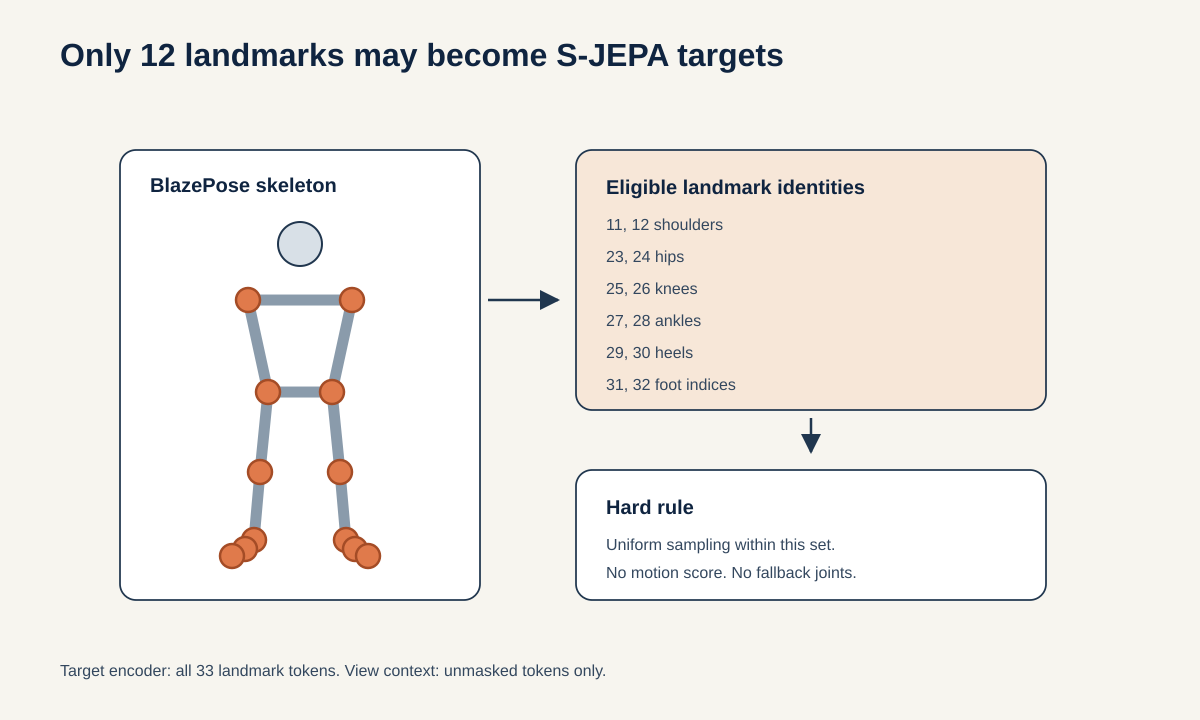

In [2]:
show_tutorial_svg("03_neurologic_mask.svg")


In [3]:
BLAZEPOSE_33 = [
    "NOSE", "LEFT_EYE_INNER", "LEFT_EYE", "LEFT_EYE_OUTER",
    "RIGHT_EYE_INNER", "RIGHT_EYE", "RIGHT_EYE_OUTER", "LEFT_EAR",
    "RIGHT_EAR", "MOUTH_LEFT", "MOUTH_RIGHT", "LEFT_SHOULDER",
    "RIGHT_SHOULDER", "LEFT_ELBOW", "RIGHT_ELBOW", "LEFT_WRIST",
    "RIGHT_WRIST", "LEFT_PINKY", "RIGHT_PINKY", "LEFT_INDEX",
    "RIGHT_INDEX", "LEFT_THUMB", "RIGHT_THUMB", "LEFT_HIP",
    "RIGHT_HIP", "LEFT_KNEE", "RIGHT_KNEE", "LEFT_ANKLE",
    "RIGHT_ANKLE", "LEFT_HEEL", "RIGHT_HEEL", "LEFT_FOOT_INDEX",
    "RIGHT_FOOT_INDEX",
]
MASK_KEYPOINTS = [11, 12, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]
MASK_KEYPOINT_NAMES = [
    "LEFT_SHOULDER", "RIGHT_SHOULDER", "LEFT_HIP", "RIGHT_HIP",
    "LEFT_KNEE", "RIGHT_KNEE", "LEFT_ANKLE", "RIGHT_ANKLE",
    "LEFT_HEEL", "RIGHT_HEEL", "LEFT_FOOT_INDEX", "RIGHT_FOOT_INDEX",
]
assert MASK_KEYPOINTS == sorted(set(MASK_KEYPOINTS))
assert [BLAZEPOSE_33[i] for i in MASK_KEYPOINTS] == MASK_KEYPOINT_NAMES


MAPPING_RELATIVE_PATH = Path(
    "experiments/multiple-sclerosis/mapping-data/ms-pd-mapping.md"
)
MAPPING_PATH = PROJECT_ROOT / MAPPING_RELATIVE_PATH
if not MAPPING_PATH.is_file():
    raise FileNotFoundError(f"Required mapping file is missing: {MAPPING_PATH}")

MASK_FEATURES_BY_INDEX = {
    11: ("shoulder_symmetry_index", "trunk_lean_angle"),
    12: ("shoulder_symmetry_index", "trunk_lean_angle"),
    23: ("walking_speed_ms", "left/right_knee_range", "hip_asymmetry", "trunk_lean_angle"),
    24: ("walking_speed_ms", "left/right_knee_range", "hip_asymmetry", "trunk_lean_angle"),
    25: ("left/right_knee_range", "left/right_ankle_range"),
    26: ("left/right_knee_range", "left/right_ankle_range"),
    27: ("left/right_knee_range", "left/right_ankle_range", "step_width_m"),
    28: ("left/right_knee_range", "left/right_ankle_range", "step_width_m"),
    29: ("stride_length_m", "double_support_percentage", "stride_time_cv", "left/right_ankle_range"),
    30: ("stride_length_m", "double_support_percentage", "stride_time_cv", "left/right_ankle_range"),
    31: ("stride_length_m", "double_support_percentage", "stride_time_cv", "left/right_ankle_range"),
    32: ("stride_length_m", "double_support_percentage", "stride_time_cv", "left/right_ankle_range"),
}
assert set(MASK_FEATURES_BY_INDEX) == set(MASK_KEYPOINTS)
mapping_text = MAPPING_PATH.read_text(encoding="utf-8")
assert all(f"({index})" in mapping_text for index in [11, 12, 23, 24, 25, 26, 27, 28, 31, 32])
assert "29–32" in mapping_text and "29,30" in mapping_text
print("mapping source:", MAPPING_RELATIVE_PATH)


mapping source: experiments/multiple-sclerosis/mapping-data/ms-pd-mapping.md


## Step 1 of 7. The eligible landmark list, and where it comes from

**The provenance rule.** The only source for this whitelist is `experiments/multiple-sclerosis/mapping-data/ms-pd-mapping.md`. Nothing was added because it seemed reasonable. The cell above asserts against that file precisely so the list cannot drift away from its source without the notebook failing.

**How the source becomes a list.** The mapping document names landmarks in prose, sometimes more than once and sometimes as inclusive ranges such as "Feet (29–32)". Those ranges are expanded, the result is de-duplicated by BlazePose index, and the indices are sorted numerically. What comes out is 12 landmark identities, forming six bilateral pairs: shoulders, hips, knees, ankles, heels, and foot indices. Everything from the elbows up and the wrists outward is excluded, as is the entire face.

**An important limit on what the source claims.** The mapping document maps MS and PD gait features to landmarks. It does not claim that these landmarks diagnose any of the five GAVD groups, and neither does this tutorial. The list is a statement about which body points gait metrics are computed from, not a statement about disease.

**One version note.** The current contract uses these 12 eligible landmark identities. A superseded legacy experiment used 10. If you meet the number 10 in older material, it describes a different, replaced model, not this one.

|BLAZEPOSE_33 index|Keypoint name|Features involved|
|---:|---|---|
|11|LEFT_SHOULDER|`shoulder_symmetry_index`, `trunk_lean_angle`|
|12|RIGHT_SHOULDER|`shoulder_symmetry_index`, `trunk_lean_angle`|
|23|LEFT_HIP|`walking_speed_ms`, `left/right_knee_range`, `hip_asymmetry`, `trunk_lean_angle`|
|24|RIGHT_HIP|`walking_speed_ms`, `left/right_knee_range`, `hip_asymmetry`, `trunk_lean_angle`|
|25|LEFT_KNEE|`left/right_knee_range`, `left/right_ankle_range`|
|26|RIGHT_KNEE|`left/right_knee_range`, `left/right_ankle_range`|
|27|LEFT_ANKLE|`left/right_knee_range`, `left/right_ankle_range`, `step_width_m`|
|28|RIGHT_ANKLE|`left/right_knee_range`, `left/right_ankle_range`, `step_width_m`|
|29|LEFT_HEEL|`stride_length_m`, `double_support_percentage`, `stride_time_cv`, `left/right_ankle_range`|
|30|RIGHT_HEEL|`stride_length_m`, `double_support_percentage`, `stride_time_cv`, `left/right_ankle_range`|
|31|LEFT_FOOT_INDEX|`stride_length_m`, `double_support_percentage`, `stride_time_cv`, `left/right_ankle_range`|
|32|RIGHT_FOOT_INDEX|`stride_length_m`, `double_support_percentage`, `stride_time_cv`, `left/right_ankle_range`|

Recall from notebook 02 that the heels, indices 29 and 30, were the least confidently detected of all 12. They are also, per this table, the landmarks the most gait features depend on. That tension does not have a fix in this project; it is a limitation to carry forward.


## Step 2 of 7. The restriction is about targets, not context

This is the distinction most readers get wrong on a first pass, so state it in both directions.

**What the 12 landmarks restrict.** Only which tokens are eligible to be **removed from the view encoder's input and predicted**. That is the entire scope of the rule.

**What they do not restrict.** What either encoder is allowed to see. The target encoder receives all 33 landmarks, unmasked, exactly as notebook 00 step 5 requires: its latents have to be contextual, so it needs the whole body. The view encoder also sees every token that was not selected, including all 21 non-eligible landmarks, every frame of them. So a wrist is never a prediction target, but a wrist is always available as context for predicting an ankle.

**Why restrict targets at all.** Because the prediction objective is what shapes the representation. Directing every target at the 12 landmarks that gait metrics are computed from spends the model's predictive capacity on the parts of the body this project is about, without blinding the encoder to the rest.

**The eligible set, formally.** For temporal segment index s and allowed landmark set K:

\[
\mathcal{E} = \{(s,j): s \in [0,S), j \in K\}
\]

The sampler draws uniformly without replacement from this eligible set, intersected with the validity mask from notebook 02. It never reads coordinate magnitude, velocity, acceleration, topology weights, or a motion score. Step 6 lists everything it deliberately does not do.

**What the next cell defines.** `uniform_neurologic_mask`, which takes a per-patch validity array of shape `[B, S, 33]` and returns a mask of the same shape where `True` means hidden from the view encoder; and `mask_audit`, which measures what the sampler actually produced. Notebook 04 imports both of these unchanged and calls them once per training batch.


In [4]:
def uniform_neurologic_mask(valid_patch, mask_fraction=0.60, seed=None):
    """Sample eligible joint-time tokens uniformly, without motion scores.

    valid_patch has shape [B, S, V]. True means that a patch can be a target.
    The returned mask has the same shape. True means hidden from the view encoder.
    """
    valid_patch = np.asarray(valid_patch, dtype=bool)
    if valid_patch.ndim != 3 or valid_patch.shape[2] != 33:
        raise ValueError(f"Expected [B, S, 33], received {valid_patch.shape}")
    if not 0.0 < mask_fraction < 1.0:
        raise ValueError("mask_fraction must be between 0 and 1")
    rng = np.random.default_rng(seed)
    eligible_joint = np.zeros(33, dtype=bool)
    eligible_joint[MASK_KEYPOINTS] = True
    eligible = valid_patch & eligible_joint[None, None, :]
    counts = eligible.reshape(len(eligible), -1).sum(axis=1)
    if np.any(counts < 2):
        raise ValueError("Each sample needs at least two valid eligible tokens")
    n_mask = max(1, int(np.floor(counts.min() * mask_fraction)))
    n_mask = min(n_mask, int(counts.min()) - 1)
    mask = np.zeros_like(eligible)
    for batch_index in range(len(mask)):
        candidates = np.flatnonzero(eligible[batch_index].reshape(-1))
        chosen = rng.choice(candidates, size=n_mask, replace=False)
        mask[batch_index].reshape(-1)[chosen] = True
    forbidden = sorted(set(range(33)).difference(MASK_KEYPOINTS))
    assert not mask[:, :, forbidden].any()
    assert mask.reshape(len(mask), -1).any(axis=1).all()
    assert (~mask).reshape(len(mask), -1).any(axis=1).all()
    return mask


def mask_audit(mask, valid_patch):
    mask = np.asarray(mask, dtype=bool)
    valid_patch = np.asarray(valid_patch, dtype=bool)
    eligible_joint = np.zeros(33, dtype=bool)
    eligible_joint[MASK_KEYPOINTS] = True
    eligible = valid_patch & eligible_joint[None, None, :]
    masked_counts = mask.reshape(len(mask), -1).sum(axis=1)
    eligible_counts = eligible.reshape(len(mask), -1).sum(axis=1)
    per_sample_ratio = masked_counts / eligible_counts
    touched = np.flatnonzero(mask.any(axis=(0, 1))).tolist()
    return {
        "masked_keypoints": touched,
        "masked_names": [BLAZEPOSE_33[i] for i in touched],
        "global_fraction": float(mask.mean()),
        "eligible_mask_fraction_min": float(per_sample_ratio.min()),
        "eligible_mask_fraction_mean": float(per_sample_ratio.mean()),
        "eligible_mask_fraction_max": float(per_sample_ratio.max()),
        "forbidden_count": int(mask[:, :, sorted(set(range(33)) - set(MASK_KEYPOINTS))].sum()),
    }


## Step 3 of 7. Create one mask and audit it

**What the next cell does.** It builds a deliberately small, deliberately imperfect example: a batch of 4 samples, 16 temporal segments, 33 landmarks. Every patch starts valid, and then two patches are invalidated, `valid_patch[0, 3:5, 27] = False`, which marks the LEFT_ANKLE of sample 0 as untrackable in segments 3 and 4.

**Why introduce a defect on purpose.** A validity matrix like this is how notebook 02's tracking failures arrive here: a landmark that was missing in any frame of a segment makes that whole segment's patch invalid, so it is excluded from the target pool. That is quality control, not motion-aware selection, and the distinction matters because motion-aware selection is prohibited. Making one sample worse than the others is also what exposes the batch rule in step 4; with a perfectly clean batch the rule would be invisible.

**Do the arithmetic before reading the output.** Sample 0 has `16 x 12 - 2 = 190` eligible tokens. Samples 1, 2, and 3 have `16 x 12 = 192` each.

**What to look at in the output.** Four fields of the audit dictionary:

- `masked_keypoints` and `masked_names` list exactly the 12 eligible indices, and `forbidden_count` is `0`. The sampler stayed inside the whitelist.
- `eligible_mask_fraction_max` is `0.6`. That is sample 0, the damaged one.
- `eligible_mask_fraction_min` is `0.59375`. That is the three clean samples.
- `global_fraction` is `0.2159...`, a much smaller number that is measured against all 33 landmarks rather than the 12 eligible ones.

The surprise worth sitting with: the sample with **fewer** eligible tokens is the one masked at the full 0.60, and the three healthy samples are masked at less. Step 4 explains why.


In [5]:
batch_size, segments, joints = 4, 16, 33
valid_patch = np.ones((batch_size, segments, joints), dtype=bool)
valid_patch[0, 3:5, 27] = False
mask = uniform_neurologic_mask(
    valid_patch,
    mask_fraction=0.60,
    seed=42,
)
audit = mask_audit(mask, valid_patch)
audit


{'masked_keypoints': [11, 12, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32],
 'masked_names': ['LEFT_SHOULDER',
  'RIGHT_SHOULDER',
  'LEFT_HIP',
  'RIGHT_HIP',
  'LEFT_KNEE',
  'RIGHT_KNEE',
  'LEFT_ANKLE',
  'RIGHT_ANKLE',
  'LEFT_HEEL',
  'RIGHT_HEEL',
  'LEFT_FOOT_INDEX',
  'RIGHT_FOOT_INDEX'],
 'global_fraction': 0.2159090909090909,
 'eligible_mask_fraction_min': 0.59375,
 'eligible_mask_fraction_mean': 0.5953125,
 'eligible_mask_fraction_max': 0.6,
 'forbidden_count': 0}

## Step 4 of 7. Why the realized fraction is not 0.60 per sample

**The rule, stated exactly.** The sampler computes one target count for the whole batch:

```text
n_mask = floor( min(eligible_counts) * mask_fraction )
```

bounded below by 1 and above by `min(eligible_counts) - 1`, and then hides exactly `n_mask` tokens in **every** sample. So `mask_fraction = 0.60` is applied once, to the smallest eligible-token count in the batch. It is **not** a guarantee that any given sample has 60 percent of its own eligible tokens hidden, and for every sample above the batch minimum the realized fraction is strictly lower.

**Check it against step 3's numbers.** The minimum is 190, so `n_mask = floor(190 * 0.60) = 114`. Sample 0 gets `114 / 190 = 0.600`, and the three clean samples get `114 / 192 = 0.59375`. The mean across the batch is `0.5953125`. Every number in step 3's audit follows from that one line.

**Why the rule has to be written this way.** The view encoder packs the visible tokens of a batch into one dense tensor, so every sample must keep the same number of tokens; the encoder in notebooks 00 and 04 raises `Each sample must keep the same number of tokens` if they do not. A per-sample fraction would give different samples different token counts and break that packing. Taking the batch minimum is the choice that keeps counts equal without ever selecting an invalid token as a target. The upper bound of `min - 1` guarantees at least one eligible token stays visible in every sample.

**What this cost during real training.** Because the count follows the worst-tracked sample in each batch, the realized fraction falls as the corpus admits more poorly tracked sequences. Averaged over each stage, the mean realized eligible fraction was **0.549 at Stage 0** and **0.421 at Stage 4**, read from the curriculum training history. The drop across the curriculum is the arithmetic above interacting with notebook 02's coverage differences, not a change of setting: `mask_fraction` stayed at 0.60 throughout. Any statement that this model masks exactly 60 percent of eligible tokens per sample is wrong.

**Why not simply match the paper's ratio.** The next cell prints the ceiling that makes this impossible. With 12 of 33 landmarks eligible, the largest global fraction reachable is `12 / 33 = 0.364`, even if every eligible token in every segment were hidden. The paper's 90 percent global ratio could only be met by masking forbidden landmarks, so this adaptation does not attempt it. The valid-eligible fraction is therefore always the meaningful number here, and the global fraction is reported alongside it only to prevent the two from being confused.

**What to look at in the output.** Five printed lines. `maximum possible global fraction: 0.364` is the structural ceiling just described. The three valid-eligible lines, `0.594`, `0.595`, and `0.600`, are the minimum, mean, and maximum from step 3, now rounded. `realized global fraction: 0.216` is what those same 114 hidden tokens amount to when measured against all 33 landmarks.


In [6]:
allowed_capacity = len(MASK_KEYPOINTS) / 33
print(f"maximum possible global fraction: {allowed_capacity:.3f}")
print(f"minimum valid-eligible fraction: {audit['eligible_mask_fraction_min']:.3f}")
print(f"mean valid-eligible fraction: {audit['eligible_mask_fraction_mean']:.3f}")
print(f"maximum valid-eligible fraction: {audit['eligible_mask_fraction_max']:.3f}")
print(f"realized global fraction: {audit['global_fraction']:.3f}")


maximum possible global fraction: 0.364
minimum valid-eligible fraction: 0.594
mean valid-eligible fraction: 0.595
maximum valid-eligible fraction: 0.600
realized global fraction: 0.216


## Step 5 of 7. Attack the sampler with adversarial invariants

**Why bother, when step 3 already looked correct.** Because step 3 inspected one mask and found nothing wrong, which is weak evidence. The checks below are the properties that must hold for *every* mask, and they are the properties a future refactor is most likely to break silently. These checks are intentionally redundant with the assertions inside the sampler itself: a refactor that removes an internal assertion should still fail here.

**What the next cell checks, and what each check rules out.**

- Shape is unchanged, so the mask still lines up with the validity array it came from.
- No forbidden index is masked, and the set of touched indices is a subset of `MASK_KEYPOINTS`. This is the whitelist itself. If it fails, the model has been predicting a wrist or a face landmark.
- Every sample has at least one masked token, so no sample silently contributes nothing to the JEPA loss.
- Every sample has at least one visible token, so the view encoder is never handed an empty input.
- The same seed reproduces the same mask, and a different seed does not. This rules out both a sampler that ignores its seed, which would make runs unreproducible, and one that ignores randomness, which would mask the same tokens forever.
- All samples have equal masked counts. This is the packing constraint from step 4, checked directly.
- `forbidden_count` from the audit is zero, which checks the auditor against the sampler rather than trusting either alone.

**What to look at in the output.** A single line, `All mask invariants passed.` These are assertions, so the informative outcome is the absence of a traceback. A future refactor that violates the whitelist will stop the notebook here rather than quietly training a different model.


In [7]:
forbidden = sorted(set(range(33)) - set(MASK_KEYPOINTS))
assert mask.shape == (batch_size, segments, 33)
assert not mask[:, :, forbidden].any()
assert mask.reshape(batch_size, -1).any(axis=1).all()
assert (~mask).reshape(batch_size, -1).any(axis=1).all()
assert set(np.where(mask.any(axis=(0, 1)))[0]).issubset(MASK_KEYPOINTS)

same_seed = uniform_neurologic_mask(valid_patch, 0.60, seed=42)
different_seed = uniform_neurologic_mask(valid_patch, 0.60, seed=43)
assert np.array_equal(mask, same_seed)
assert not np.array_equal(mask, different_seed)

counts = mask.reshape(batch_size, -1).sum(axis=1)
assert np.all(counts == counts[0])
assert audit["forbidden_count"] == 0
print("All mask invariants passed.")


All mask invariants passed.


## Step 6 of 7. The policies that are explicitly absent

Listing what a component does is not enough when the point of the component is what it refuses to do. Notebook 00 steps 3 and 4 described two neighbouring methods whose samplers use motion and topology. None of the following exists in this sampler:

- No per-joint motion magnitude.
- No temporal difference score.
- No softmax over motion intensity.
- No Gumbel ranking from motion probabilities.
- No topology group expansion.
- No second random draw over temporal blocks.
- No fallback to another joint when an eligible target is unavailable.

The last one deserves a sentence of its own. When a landmark is invalid, its token is simply dropped from the eligible pool and the target count adjusts, as step 4 described. It is never replaced by a substitute landmark, because a substitute drawn from outside the whitelist would break the target restriction in exactly the way step 5's first check exists to detect.

The sampler always produces at least one target and leaves at least one visible token per sample, and it applies `mask_fraction` exactly once per batch, in the single `floor` expression from step 4.


## Step 7 of 7. Why targets are stochastic rather than permanently hidden

**The alternative that was rejected.** One could simply hide all 12 eligible landmarks in every sample, always. That would be simpler and it would satisfy the target restriction.

**Why it would be worse.** A permanently hidden landmark never appears on the view encoder's input side, so its patch embedding would receive no direct gradient at all, ever. The model would be asked to predict 12 landmarks whose input representations it had no way to learn.

**What the stochastic rule buys instead.** Because a fresh draw is made for every batch, each neurologically relevant token is sometimes visible and sometimes predicted. It therefore learns its patch embedding directly on the batches where it is visible, while still being a frequent latent target on the batches where it is not.

### What was established, and what remains open

Established: the eligible set is 12 landmark identities traceable to a named mapping document; the restriction applies to targets only, and both encoders still see the whole body; the 0.60 fraction is applied once per batch to the smallest eligible-token count, giving realized means of 0.549 at Stage 0 and 0.421 at Stage 4; and the sampler passes a set of adversarial invariants including the whitelist itself.

Open: whether any of this helps. This notebook shows that the masking rule is correctly implemented and correctly described. It does not show that restricting targets to 12 landmarks produces a better representation than not restricting them, because no ablation against an unrestricted sampler was run. Treat the restriction as a documented design choice, not as a validated one.

**Next:** notebook 04 uses this exact mask function, unchanged, in normal-only Stage 0 and in every progressive continuation stage, drawing a new mask for each training batch.
